In [3]:
import geopandas as gpd
import pandas as pd
import libpysal as lps
from sklearn.neighbors import NearestNeighbors
import numpy as np
import esda

import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Input, Dropout # type: ignore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [4]:
# handle pre-processing
def get_numeric_cols(dataset):
    # numeric columns except for latitude and longitude
    numeric_cols = dataset.select_dtypes(include=['number']).columns
    numeric_cols = numeric_cols.drop(LAT_LONG_COLS)
    return numeric_cols

# Calculate organic matter metrics if orgc present
def om_bd_columns(df):
    if 'orgc' in df.columns:
        # Use vectorized operations for better performance
        organic_matter = 1.724 * df['orgc']
        df = df.assign(
            organic_matter=organic_matter,
            bulk_density=1.62 - 0.06 * organic_matter
        )
    return df

# Handle silt and clay columns if present
def silt_plus_clay_columns(df):
    if {'silt', 'clay'}.issubset(df.columns):
        df['silt_plus_clay'] = df[['silt', 'clay']].sum(axis=1, skipna=True)
        df.drop(columns=['silt', 'clay'], inplace=True)
    return df


In [5]:
LAT_LONG_COLS = ['latitude', 'longitude']
TARGET_COL = 'orgc'

# load raw dataset
dataset = pd.read_csv("D:/tierra/data/mexico_combined_data.csv")
# convert date to datetime
dataset['date'] = pd.to_datetime(dataset['date'].values, format='%Y-%m-%d', errors='coerce')
# keep columns with at least 30% non-missing values (accept 70% missing values)
dataset = dataset.dropna(thresh=len(dataset) * 0.3, axis=1)
# Fill missing values for all numeric columns at once
numeric_cols = get_numeric_cols(dataset)
# fill missing values with the mean of the column before adding new features
dataset[numeric_cols] = dataset[numeric_cols].fillna(dataset[numeric_cols].mean())
# add new features
df = dataset[numeric_cols.tolist() + LAT_LONG_COLS].copy()
# add organic matter and bulk density
df = om_bd_columns(df)
# add silt and clay
df = silt_plus_clay_columns(df)

df.head(10)

,upper_depth,lower_depth,elcosp,orgc,phaq,sand,tceq,temperature,precipitation,landcover,latitude,longitude,organic_matter,bulk_density,silt_plus_clay
0,0,2,1.111665,15.05821,7.231559,24.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,25.960355,0.062379,35.515567
1,0,4,1.111665,46.30000,7.231559,30.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,79.821200,-3.169272,45.515567
2,0,4,1.111665,46.30000,7.231559,30.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,79.821200,-3.169272,45.515567
3,0,4,1.111665,46.30000,7.231559,30.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,79.821200,-3.169272,34.515567
4,0,4,1.111665,46.30000,7.231559,30.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,79.821200,-3.169272,54.515567
5,0,4,1.111665,46.30000,7.231559,17.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,79.821200,-3.169272,45.515567
6,0,4,1.111665,46.30000,7.231559,17.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,79.821200,-3.169272,45.515567
7,0,4,1.111665,46.30000,7.231559,17.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,79.821200,-3.169272,34.515567
8,0,4,1.111665,46.30000,7.231559,17.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,79.821200,-3.169272,54.515567
9,0,4,1.111665,46.30000,7.231559,32.0,46.562405,15.471338,108.078063,9.691766,18.6152,-90.7319,79.821200,-3.169272,45.515567


In [6]:
# introduce grids
def load_grids(file_path):
    grid_gdf = gpd.read_file(file_path)
    return grid_gdf

# load grids
grid_gdf = load_grids("D:/tierra/data/grids/mexico/mexico_grid_10.0km.shp")

In [7]:
def spatial_join(grid_gdf, df):
    # Create GeoDataFrame with geometry and sequential grid_id
    gdf = gpd.GeoDataFrame(
        {'grid_id': range(1, len(grid_gdf) + 1)}, 
        geometry=grid_gdf.geometry,
        crs="EPSG:4326"  # Set CRS for grid GeoDataFrame
    )

    # Convert df to GeoDataFrame using latitude/longitude
    df_gdf = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df.longitude, df.latitude),
        crs="EPSG:4326"  # Set same CRS for points GeoDataFrame
    )

    # Perform spatial join between points and grid polygons
    gdf = gpd.sjoin(gdf, df_gdf, how="left", predicate="contains")

    # Drop unnecessary columns from the spatial join
    gdf = gdf.drop(columns=['index_right'], errors='ignore')

    # drop rows with missing values
    gdf = gdf.dropna()
    print(f"Spatial features: {gdf.shape} \n Columns: {gdf.columns}")
    return gdf

# spatial join
gdf = spatial_join(grid_gdf, df)

Spatial features: (8039, 17) 
 Columns: Index(['grid_id', 'geometry', 'upper_depth', 'lower_depth', 'elcosp', 'orgc',
       'phaq', 'sand', 'tceq', 'temperature', 'precipitation', 'landcover',
       'latitude', 'longitude', 'organic_matter', 'bulk_density',
       'silt_plus_clay'],
      dtype='object')


In [8]:
def preprocess_spatial_data(gdf):
    # Create a copy to avoid modifying the original dataframe
    gdf = gdf.copy()
    
    # Group by grid_id and calculate mean for all numeric columns
    numeric_columns = get_numeric_cols(gdf)
    gdf_means = gdf.groupby('grid_id')[numeric_columns].mean()

    # Replace original values with mean values for each grid_id
    for col in numeric_columns:
        if col != 'grid_id':
            gdf.loc[:, col] = gdf['grid_id'].map(gdf_means[col])

    # remove duplicate rows
    gdf = gdf.drop_duplicates()

    # replace missing values with the mean of the column
    column_means = gdf[numeric_columns].mean()
    gdf.loc[:, numeric_columns] = gdf[numeric_columns].fillna(column_means)
    
    print(f"Preprocessed data: {gdf.shape} \n Columns: {gdf.columns}")
    
    return gdf
# preprocess spatial data
gdf = preprocess_spatial_data(gdf)

Preprocessed data: (6675, 17) 
 Columns: Index(['grid_id', 'geometry', 'upper_depth', 'lower_depth', 'elcosp', 'orgc',
       'phaq', 'sand', 'tceq', 'temperature', 'precipitation', 'landcover',
       'latitude', 'longitude', 'organic_matter', 'bulk_density',
       'silt_plus_clay'],
      dtype='object')


In [9]:
def spatial_features(gdf):
    if len(gdf) == 0:
        return gdf
        
    # Project to a suitable projected CRS for accurate geometric operations
    gdf = gdf.to_crs("EPSG:6372")  # Mexico Lambert Conformal Conic
        
    # spatial lag using queen contiguity
    y = gdf[TARGET_COL]
    wq = lps.weights.Queen.from_dataframe(gdf, use_index=False)
    wq.transform = 'r'  # Row-standardize weights
    
    # Handle disconnected components by setting spatial lag to 0 for islands
    try:
        gdf['spatial_lag'] = lps.weights.lag_spatial(wq, y)
    except:
        gdf['spatial_lag'] = 0

    # Calculate local Moran's I with handling for invalid values
    try:
        li = esda.moran.Moran_Local(y, wq)
        # Handle invalid values in Is and z_sim calculation
        Is = li.Is
        # Replace inf/nan in Is with 0
        Is = np.nan_to_num(Is, nan=0.0, posinf=0.0, neginf=0.0)
        # Handle division by zero in z-score calculation
        with np.errstate(divide='ignore', invalid='ignore'):
            z_sim = (Is - li.EI_sim) / li.seI_sim
            z_sim = np.nan_to_num(z_sim, nan=0.0, posinf=0.0, neginf=0.0)
        # Calculate significance based on z-scores
        sig = (np.abs(z_sim) > 1.96).astype(int)
        quadrants = np.nan_to_num(li.q, nan=0)
    except:
        Is = np.zeros(len(gdf))
        sig = np.zeros(len(gdf))
        quadrants = np.zeros(len(gdf))
    
    gdf['moran_i'] = Is
    gdf['hotspot'] = sig * (quadrants == 1)
    gdf['coldspot'] = sig * (quadrants == 3)
    gdf['doughnut'] = sig * (quadrants == 2) 
    gdf['diamond'] = sig * (quadrants == 4)
    
    # Binary classification based on hotspots
    gdf['target_binary'] = gdf['hotspot']

    # KNN for nearest neighbors analysis
    centroids = gdf.geometry.centroid
    coords = np.column_stack((centroids.x, centroids.y))
    
    # Optimize k based on dataset size
    k = min(5, len(gdf)-1)  # Ensure k doesn't exceed dataset size
    if k > 0:
        nn = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree')
        nn.fit(coords)
        distances, indices = nn.kneighbors(coords)
        
        # Calculate mean distance and target values of k nearest neighbors
        gdf['mean_dist_knn'] = distances[:, 1:].mean(axis=1)
        target_values = y.values
        gdf['knn_target_mean'] = np.array([
            target_values[indices[i, 1:]].mean() for i in range(len(gdf))
        ])
    else:
        gdf['mean_dist_knn'] = 0
        gdf['knn_target_mean'] = y

    # Calculate distance to nearest hotspot more efficiently
    hotspots = gdf[gdf['target_binary'] == 1]
    if len(hotspots) > 0:
        # Use spatial index for faster distance calculations
        hotspots_geom = hotspots.geometry
        gdf['dist_to_hotspot'] = gdf.geometry.apply(
            lambda x: min(x.distance(hs) for hs in hotspots_geom)
        )
    else:
        gdf['dist_to_hotspot'] = 0

    # Convert back to geographic CRS
    gdf = gdf.to_crs("EPSG:4326")
    
    return gdf


# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# add spatial features
gdf = spatial_features(gdf)

('WARNING: ', 188, ' is an island (no neighbors)')
('WARNING: ', 195, ' is an island (no neighbors)')
('WARNING: ', 223, ' is an island (no neighbors)')
('WARNING: ', 306, ' is an island (no neighbors)')
('WARNING: ', 327, ' is an island (no neighbors)')
('WARNING: ', 338, ' is an island (no neighbors)')
('WARNING: ', 437, ' is an island (no neighbors)')
('WARNING: ', 441, ' is an island (no neighbors)')
('WARNING: ', 490, ' is an island (no neighbors)')
('WARNING: ', 551, ' is an island (no neighbors)')
('WARNING: ', 554, ' is an island (no neighbors)')
('WARNING: ', 587, ' is an island (no neighbors)')
('WARNING: ', 635, ' is an island (no neighbors)')
('WARNING: ', 784, ' is an island (no neighbors)')
('WARNING: ', 872, ' is an island (no neighbors)')
('WARNING: ', 873, ' is an island (no neighbors)')
('WARNING: ', 896, ' is an island (no neighbors)')
('WARNING: ', 921, ' is an island (no neighbors)')
('WARNING: ', 967, ' is an island (no neighbors)')
('WARNING: ', 1020, ' is an isl

In [10]:
# set grid_id as index
# gdf = gdf.set_index('grid_id')
pd.set_option('display.max_columns', None)
gdf.head()

,grid_id,geometry,upper_depth,lower_depth,elcosp,orgc,phaq,sand,tceq,temperature,precipitation,landcover,latitude,longitude,organic_matter,bulk_density,silt_plus_clay,spatial_lag,moran_i,hotspot,coldspot,doughnut,diamond,target_binary,mean_dist_knn,knn_target_mean,dist_to_hotspot
2,3,"POLYGON ((-117.02776 32.53883, -117.02776 32.4...",0.0,18.0,0.100000,7.00000,5.400000,61.0,0.000000,16.924751,150.516754,7.000000,32.487680,-117.079056,12.068000,0.895920,39.000000,15.058210,0.003766,0,0,0,0,0,18711.247938,14.631046,876240.965352
6,7,"POLYGON ((-117.02776 32.33883, -116.92776 32.3...",0.0,27.0,0.200000,11.00000,7.200000,30.0,46.562405,15.452024,96.698326,7.000000,32.314095,-116.995094,18.964000,0.482160,70.000000,13.881046,0.052297,0,0,0,0,0,9960.978720,12.982508,860413.494209
8,9,"POLYGON ((-117.02776 32.53883, -116.92776 32.5...",5.0,15.0,1.111665,15.05821,7.231559,31.0,46.562405,15.471338,108.078063,9.691766,32.500000,-117.000000,25.960355,0.062379,77.515567,13.524254,0.000734,0,0,0,0,0,13242.333099,14.025225,867258.380982
12,13,"POLYGON ((-116.92776 32.13883, -116.82776 32.1...",6.0,17.5,0.100000,10.00000,6.850000,52.0,23.281202,15.452024,96.698326,7.000000,32.102436,-116.870620,17.240000,0.585600,48.000000,14.543658,0.029766,0,0,0,0,0,12885.212576,13.909354,844961.196260
13,14,"POLYGON ((-116.92776 32.23883, -116.82776 32.2...",0.0,17.0,1.000000,15.05821,6.250000,41.0,46.562405,15.471338,108.078063,9.691766,32.170765,-116.866760,25.960355,0.062379,59.000000,12.550150,0.001186,0,0,0,0,0,8877.661164,12.345613,848091.008351


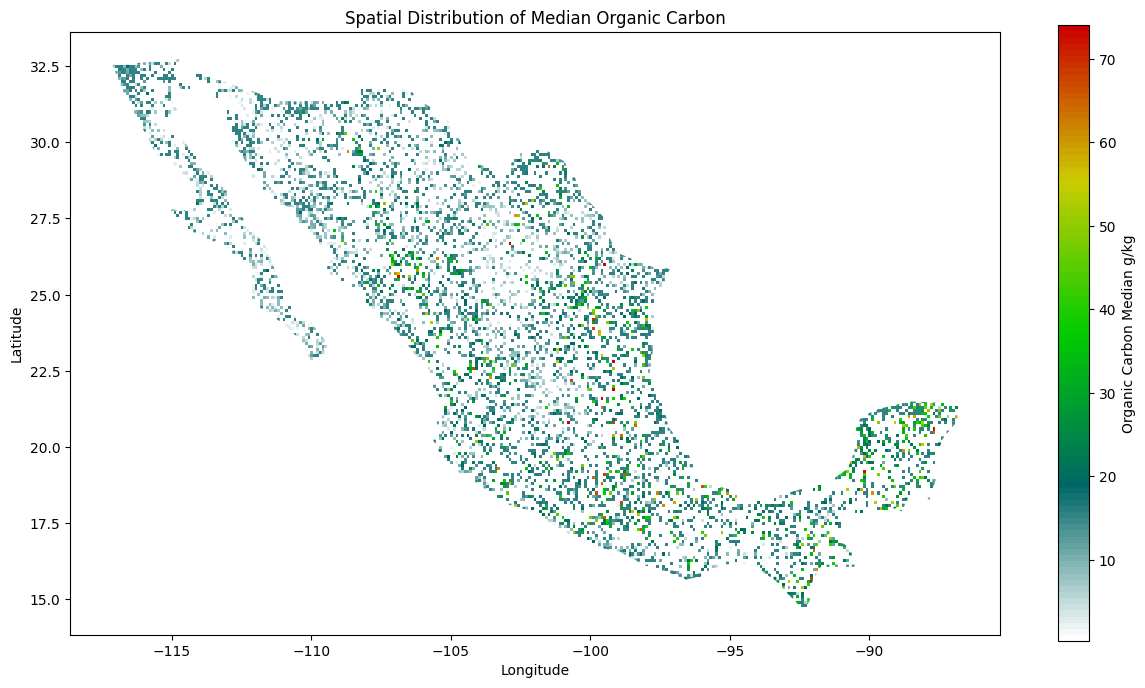

In [11]:
# Plot with colorbar
# Create custom colormap that leaves low values white
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Get min/max values excluding zeros/very small values
data = gdf[TARGET_COL]
threshold = 0.01  # Threshold for "close to zero"
vmin = data[data > threshold].min()
vmax = data.max()

# Create custom colormap starting from white
colors = [(1,1,1), (0,0.4,0.4), (0,0.8,0), (0.8,0.8,0), (0.8,0,0)]
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

# Plot with custom colormap and range
plot = gdf.plot(column=TARGET_COL, legend=True,
                legend_kwds={'label': 'Organic Carbon Median g/kg'},
                cmap=cmap, 
                vmin=vmin,
                vmax=vmax,
                figsize=(15, 8))

# Add title
plt.title('Spatial Distribution of Median Organic Carbon')

# Add axis labels
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

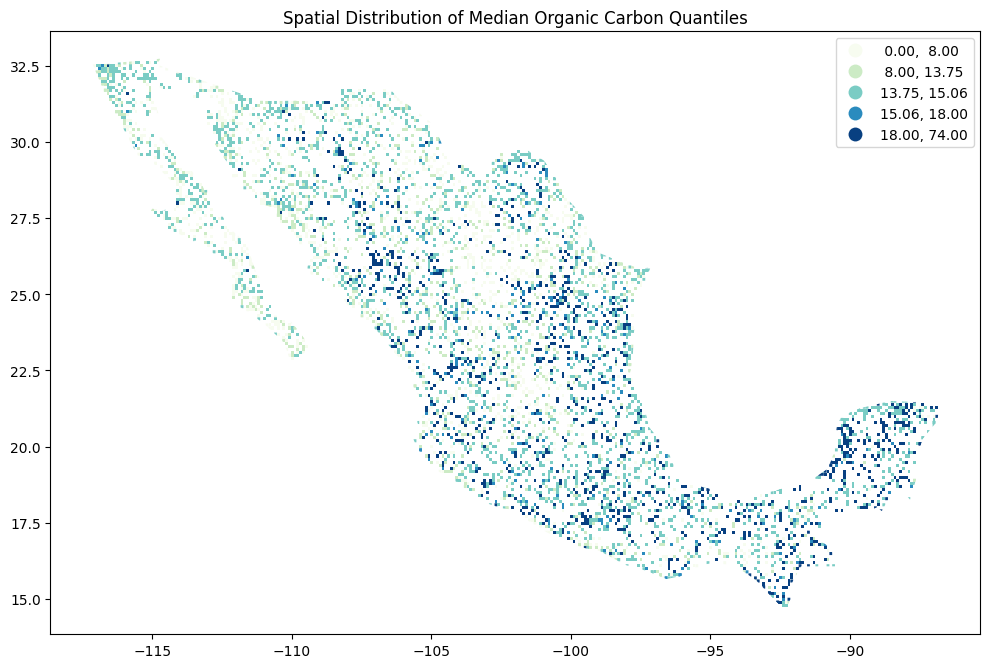

In [12]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
gdf.plot(column=TARGET_COL, scheme='Quantiles', k=5, cmap='GnBu', legend=True, ax=ax)
plt.title('Spatial Distribution of Median Organic Carbon Quantiles')
plt.show()

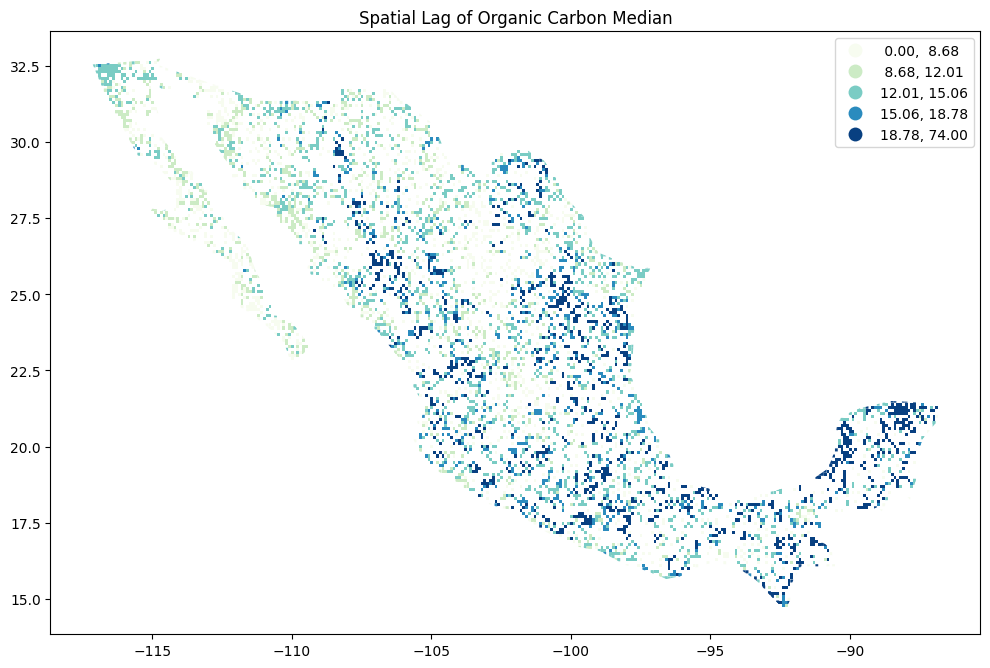

In [13]:
# plot the spatial lag
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
gdf.plot(column='spatial_lag', scheme='Quantiles', k=5, cmap='GnBu', legend=True, ax=ax)
plt.title('Spatial Lag of Organic Carbon Median')
plt.show()

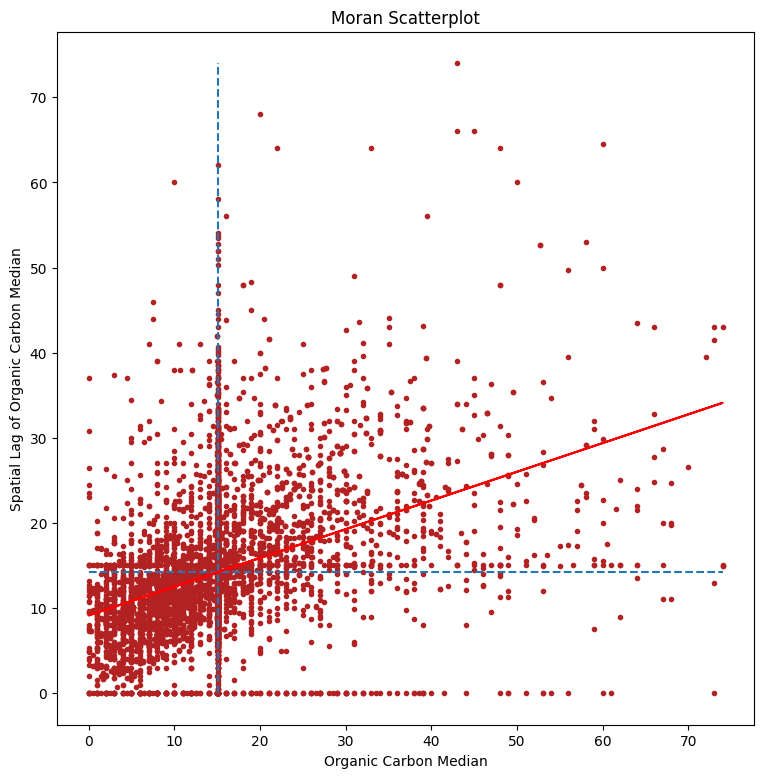

In [14]:
lag_orgc = gdf['spatial_lag']
y = gdf[TARGET_COL]

b, a = np.polyfit(y, lag_orgc, 1)
f, ax = plt.subplots(1, figsize=(9, 9))

plt.plot(y, lag_orgc, '.', color='firebrick')

# dashed vert at mean of the price
plt.vlines(y.mean(), lag_orgc.min(), lag_orgc.max(), linestyle='--')
# dashed horizontal at mean of lagged price
plt.hlines(lag_orgc.mean(), y.min(), y.max(), linestyle='--')

# red line of best fit using global I as slope
plt.plot(y, a + b*y, 'r')
plt.title('Moran Scatterplot')
plt.ylabel('Spatial Lag of Organic Carbon Median')
plt.xlabel('Organic Carbon Median')
plt.show()

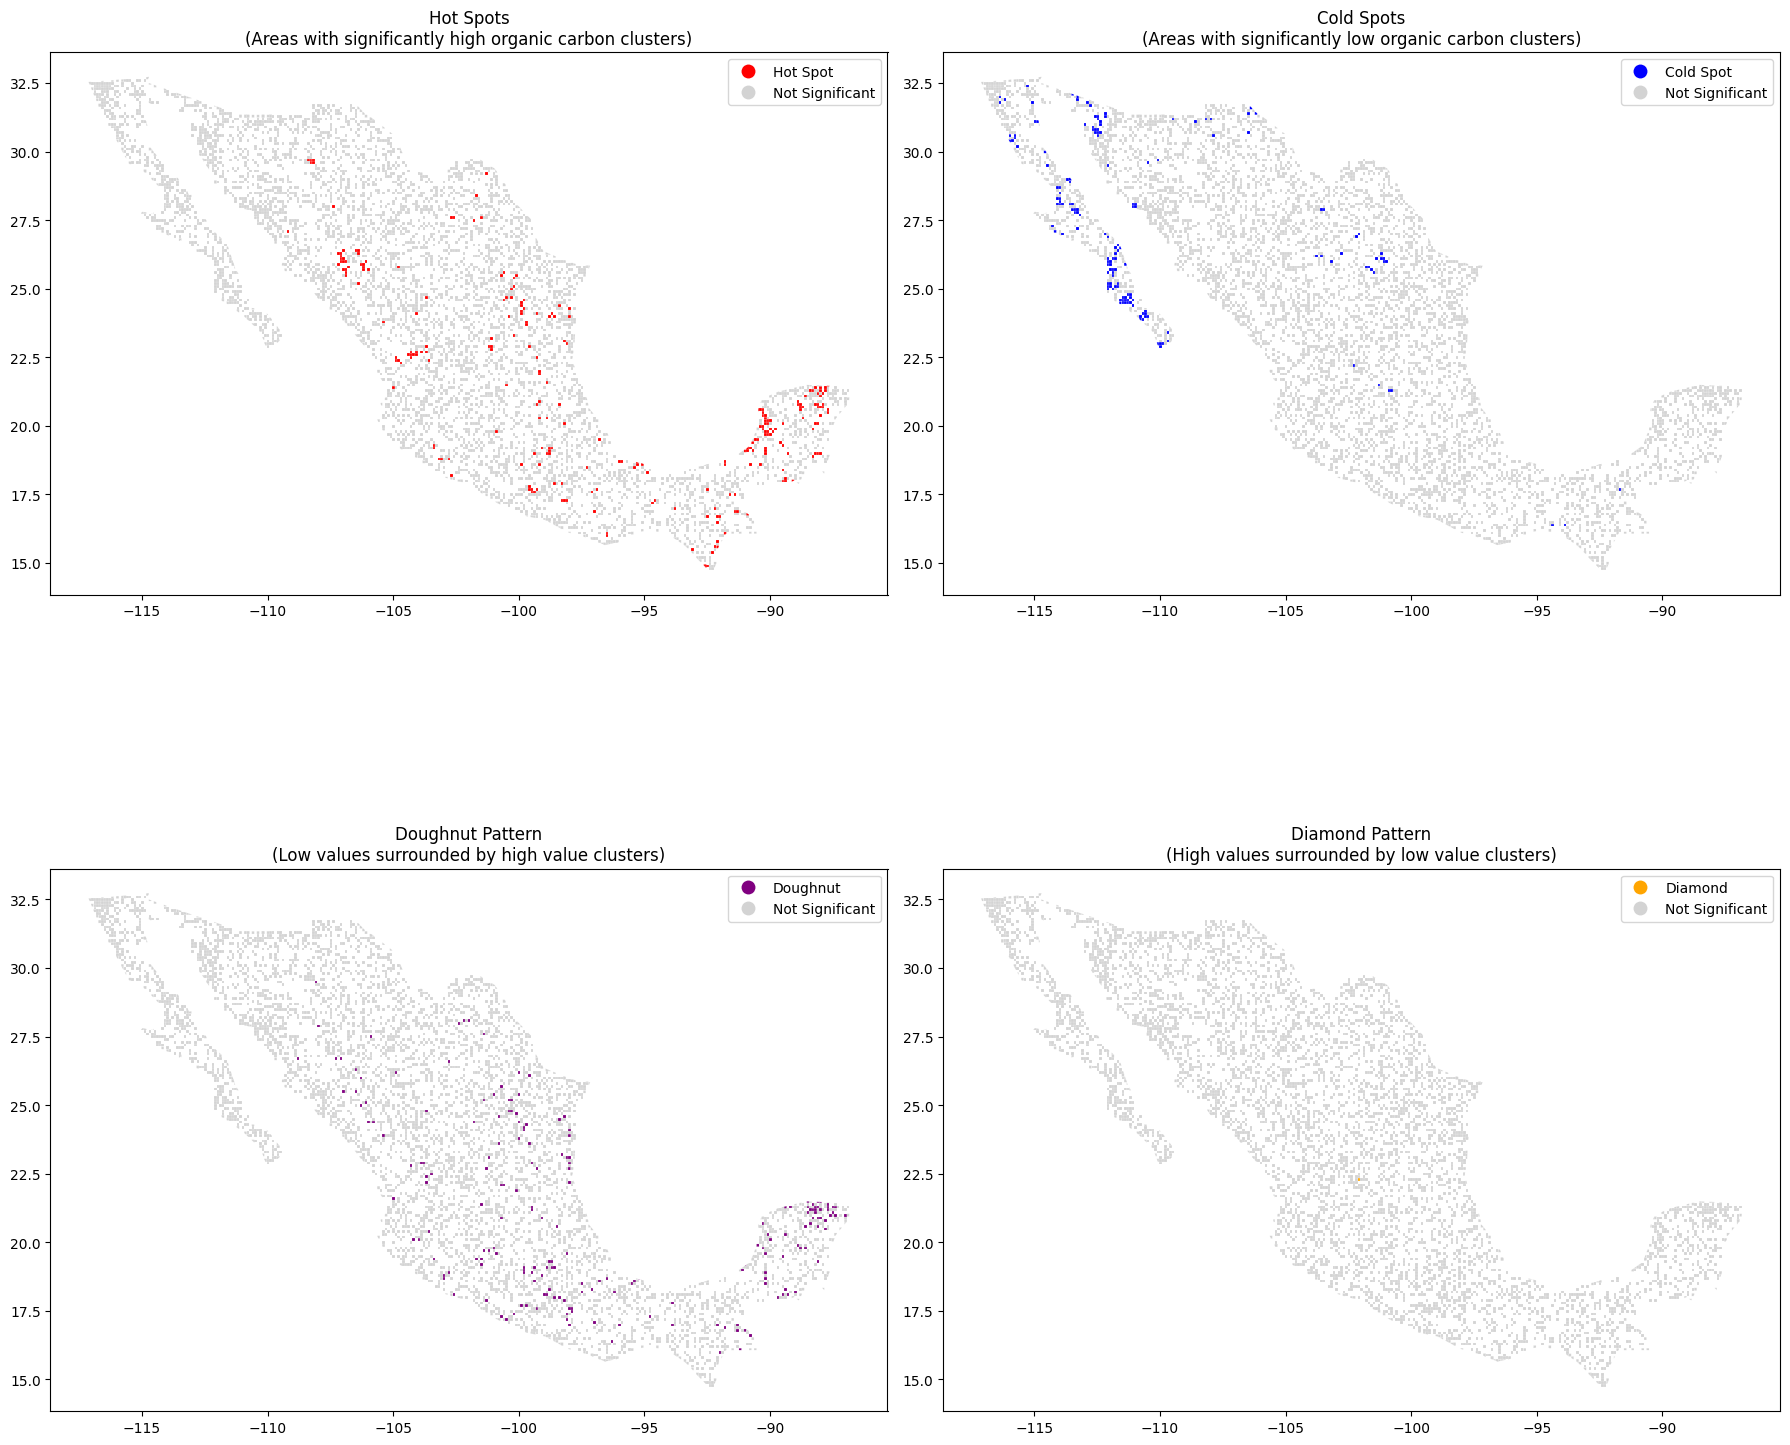

In [15]:
import matplotlib.colors as colors

def plot_moran_patterns(gdf):
    # Create 2x2 subplot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 18))

    # Plot hotspots 
    spots = ['Not Significant', 'Hot Spot']
    labels = [spots[1] if i == 1 else spots[0] for i in gdf['hotspot']]
    hmap = colors.ListedColormap(['red', 'lightgrey'])
    gdf.assign(cl=labels).plot(column='cl', categorical=True,
                            k=2, cmap=hmap, linewidth=0.1, ax=ax1,
                            edgecolor='white', legend=True)
    ax1.set_title('Hot Spots\n(Areas with significantly high organic carbon clusters)')

    # Plot coldspots
    spots = ['Not Significant', 'Cold Spot'] 
    labels = [spots[1] if i == 1 else spots[0] for i in gdf['coldspot']]
    hmap = colors.ListedColormap(['blue', 'lightgrey'])
    gdf.assign(cl=labels).plot(column='cl', categorical=True,
                            k=2, cmap=hmap, linewidth=0.1, ax=ax2,
                            edgecolor='white', legend=True)
    ax2.set_title('Cold Spots\n(Areas with significantly low organic carbon clusters)')

    # Plot doughnut
    spots = ['Not Significant', 'Doughnut']
    labels = [spots[1] if i == 1 else spots[0] for i in gdf['doughnut']]
    hmap = colors.ListedColormap(['purple', 'lightgrey'])
    gdf.assign(cl=labels).plot(column='cl', categorical=True,
                            k=2, cmap=hmap, linewidth=0.1, ax=ax3,
                            edgecolor='white', legend=True)
    ax3.set_title('Doughnut Pattern\n(Low values surrounded by high value clusters)')

    # Plot diamond
    spots = ['Not Significant', 'Diamond']
    labels = [spots[1] if i == 1 else spots[0] for i in gdf['diamond']]
    hmap = colors.ListedColormap(['orange', 'lightgrey'])
    gdf.assign(cl=labels).plot(column='cl', categorical=True,
                            k=2, cmap=hmap, linewidth=0.1, ax=ax4,
                            edgecolor='white', legend=True)
    ax4.set_title('Diamond Pattern\n(High values surrounded by low value clusters)')

    plt.tight_layout()
    plt.show()

plot_moran_patterns(gdf)

In [16]:
def scale_features(gdf, test_size=0.2, random_state=42):
    # deep learning for organic carbon prediction
    X = gdf.drop(columns=['latitude', 'longitude', 'grid_id', 'geometry', TARGET_COL])
    y = gdf[TARGET_COL]

    # split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler

def build_model(X_train):
    # build the model
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'), # first hidden layer with 64 neurons
        Dropout(0.2), # add dropout to reduce overfitting
        Dense(32, activation='relu'), # second hidden layer with 32 neurons
        Dropout(0.2), # add dropout to reduce overfitting
        Dense(1) # output layer with 1 neuron
    ])

    # compile the model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

# scale features
X_train, X_test, y_train, y_test, scalar = scale_features(gdf)
# build the model
model = build_model(X_train)

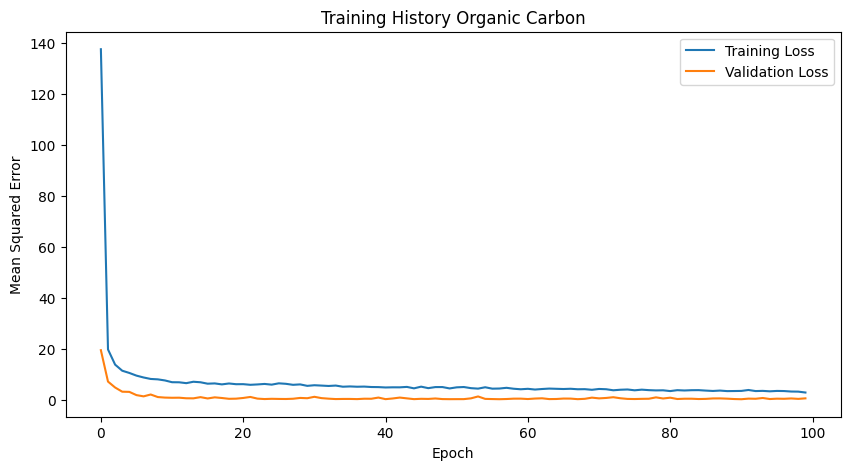

In [17]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    # train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=0)
    return history

# train the model
history = train_model(model, X_train, y_train, X_test, y_test)

# plot the training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training History Organic Carbon')
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X_test, y_test):
    """
    Evaluate deep learning model performance using multiple metrics.
    Returns dictionary of metrics and predicted values.
    """
    # Get model predictions
    y_pred = model.predict(X_test, verbose=0).flatten()
    
    # Calculate metrics using sklearn functions for better efficiency
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Get model loss
    loss = model.evaluate(X_test, y_test, verbose=0)[0]
    
    # Store metrics in dictionary
    metrics = {
        'loss': loss,
        'mae': mae, 
        'mse': mse,
        'rmse': rmse,
        'r2': r2
    }
    
    # Print formatted results
    print("\nDeep Learning Model Evaluation:")
    print("-" * 30)
    print(f"Mean Squared Error:     {metrics['mse']:.4f}")
    print(f"Root Mean Squared Error: {metrics['rmse']:.4f}")
    print(f"Mean Absolute Error:    {metrics['mae']:.4f}") 
    print(f"R² Score:              {metrics['r2']:.4f}")
    print("-" * 30)
    
    return metrics, y_pred

# Evaluate model and get metrics
metrics, y_pred = evaluate_model(model, X_test, y_test)


Deep Learning Model Evaluation:
------------------------------
Mean Squared Error:     0.5262
Root Mean Squared Error: 0.7254
Mean Absolute Error:    0.5517
R² Score:              0.9953
------------------------------


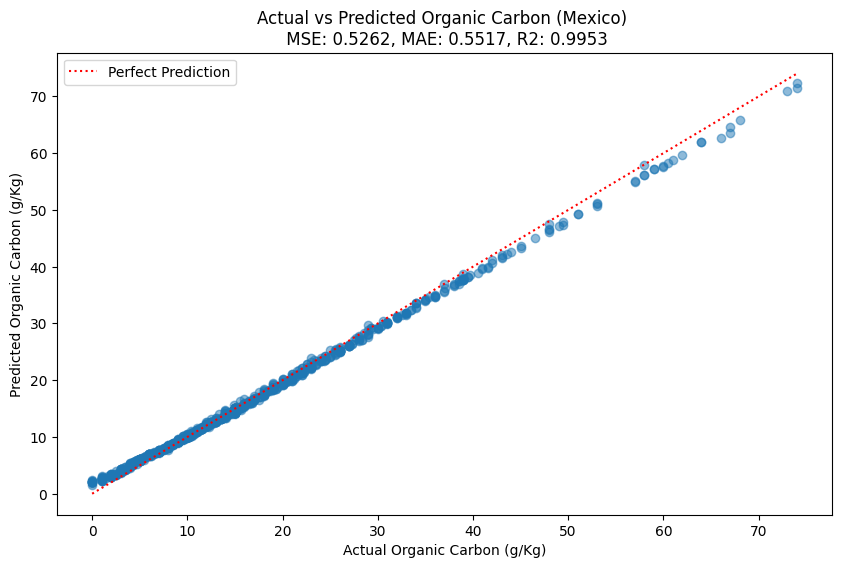

In [19]:
# plot the predictions vs the actual values
def plot_predictions(y_test, y_pred, metrics, country_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r:', label='Perfect Prediction')
    plt.xlabel('Actual Organic Carbon (g/Kg)')
    plt.ylabel('Predicted Organic Carbon (g/Kg)')
    plt.title(f'Actual vs Predicted Organic Carbon ({country_name}) \n MSE: {metrics['mse']:.4f}, MAE: {metrics['mae']:.4f}, R2: {metrics['r2']:.4f}')
    plt.legend()
    plt.show()

# plot the predictions vs the actual values
plot_predictions(y_test, y_pred, metrics, 'Mexico')

In [ ]:
import joblib
model_path = "D:/tierra/models/orgc_dl_model.pkl"
scalar_path = "D:/tierra/models/orgc_dl_scalar.pkl"

# Save the model
joblib.dump(model, model_path)
# save the scalar
joblib.dump(scalar, scalar_path)
print("Model saved successfully")

gdf.set_index('grid_id', inplace=True)
# save the preprocessed data
gdf.to_csv("D:/tierra/datasets/dl_mexico_dataset.csv")

Model saved successfully


# Testing and Evaluation of the model for different countries


In [21]:
# load the model and sclar
MODEL = joblib.load(model_path)
SCALAR = joblib.load(scalar_path)

In [24]:
# Test the model on various datasets
def preprocess_dataset(dataset):
    # convert date to datetime
    dataset['date'] = pd.to_datetime(dataset['date'].values, format='%Y-%m-%d', errors='coerce')
    # numeric columns except for latitude and longitude
    numeric_cols = get_numeric_cols(dataset)
    # add new features
    df = dataset[numeric_cols.tolist() + LAT_LONG_COLS].copy()
    # add organic matter and bulk density
    df = om_bd_columns(df)
    # add silt and clay
    df = silt_plus_clay_columns(df)

    return df

def load_test_dataset(filepath, mexico_dataset, grid_gdf):
    # load the dataset
    dataset = pd.read_csv(filepath)
    # preprocess the dataset
    df = preprocess_dataset(dataset)
    
    print("-"*30)
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns}")
    print("-"*30)
    
    # Get feature columns and ensure they exist in UK data
    feature_columns = mexico_dataset.columns
    for col in feature_columns:
        if col not in df.columns:
            df[col] = 0
        
    # numeric columns except for latitude and longitude
    numeric_cols = get_numeric_cols(df)

    # fill missing values
    df = df[feature_columns].copy()
    df = df.fillna(df.mean())

    # # spatial join
    gdf = spatial_join(grid_gdf, df)
    # # add spatial features
    gdf = spatial_features(gdf)

    return gdf

def test_model(test_gdf, model, scalar):
    # drop columns
    test_features = test_gdf.drop(columns=['geometry', 'grid_id', 'latitude', 'longitude', TARGET_COL])
    # Scale features
    test_gdf_scaled = scalar.transform(test_features)
    # split into features and target
    X_test = test_gdf_scaled
    y_test = test_gdf[TARGET_COL]
    # evaluate the model
    metrics, y_pred = evaluate_model(model, X_test, y_test)
    # plot the predictions vs the actual values
    plot_predictions(y_test, y_pred, metrics, 'United Kingdom')


## UK dataset

------------------------------
Shape: (5109, 24)
Columns: Index(['upper_depth', 'lower_depth', 'bdfiad', 'bdfiod', 'cecph7', 'cfvo',
       'nitkjd', 'orgc', 'orgm', 'phaq', 'sand', 'tceq', 'totc', 'wv0010',
       'wv0033', 'wv1500', 'temperature', 'precipitation', 'landcover',
       'latitude', 'longitude', 'organic_matter', 'bulk_density',
       'silt_plus_clay'],
      dtype='object')
------------------------------
Spatial features: (4884, 17) 
 Columns: Index(['grid_id', 'geometry', 'upper_depth', 'lower_depth', 'elcosp', 'orgc',
       'phaq', 'sand', 'tceq', 'temperature', 'precipitation', 'landcover',
       'latitude', 'longitude', 'organic_matter', 'bulk_density',
       'silt_plus_clay'],
      dtype='object')
('WARNING: ', 33, ' is an island (no neighbors)')
('WARNING: ', 39, ' is an island (no neighbors)')
('WARNING: ', 135, ' is an island (no neighbors)')
('WARNING: ', 139, ' is an island (no neighbors)')
('WARNING: ', 210, ' is an island (no neighbors)')
('WARNING: ', 

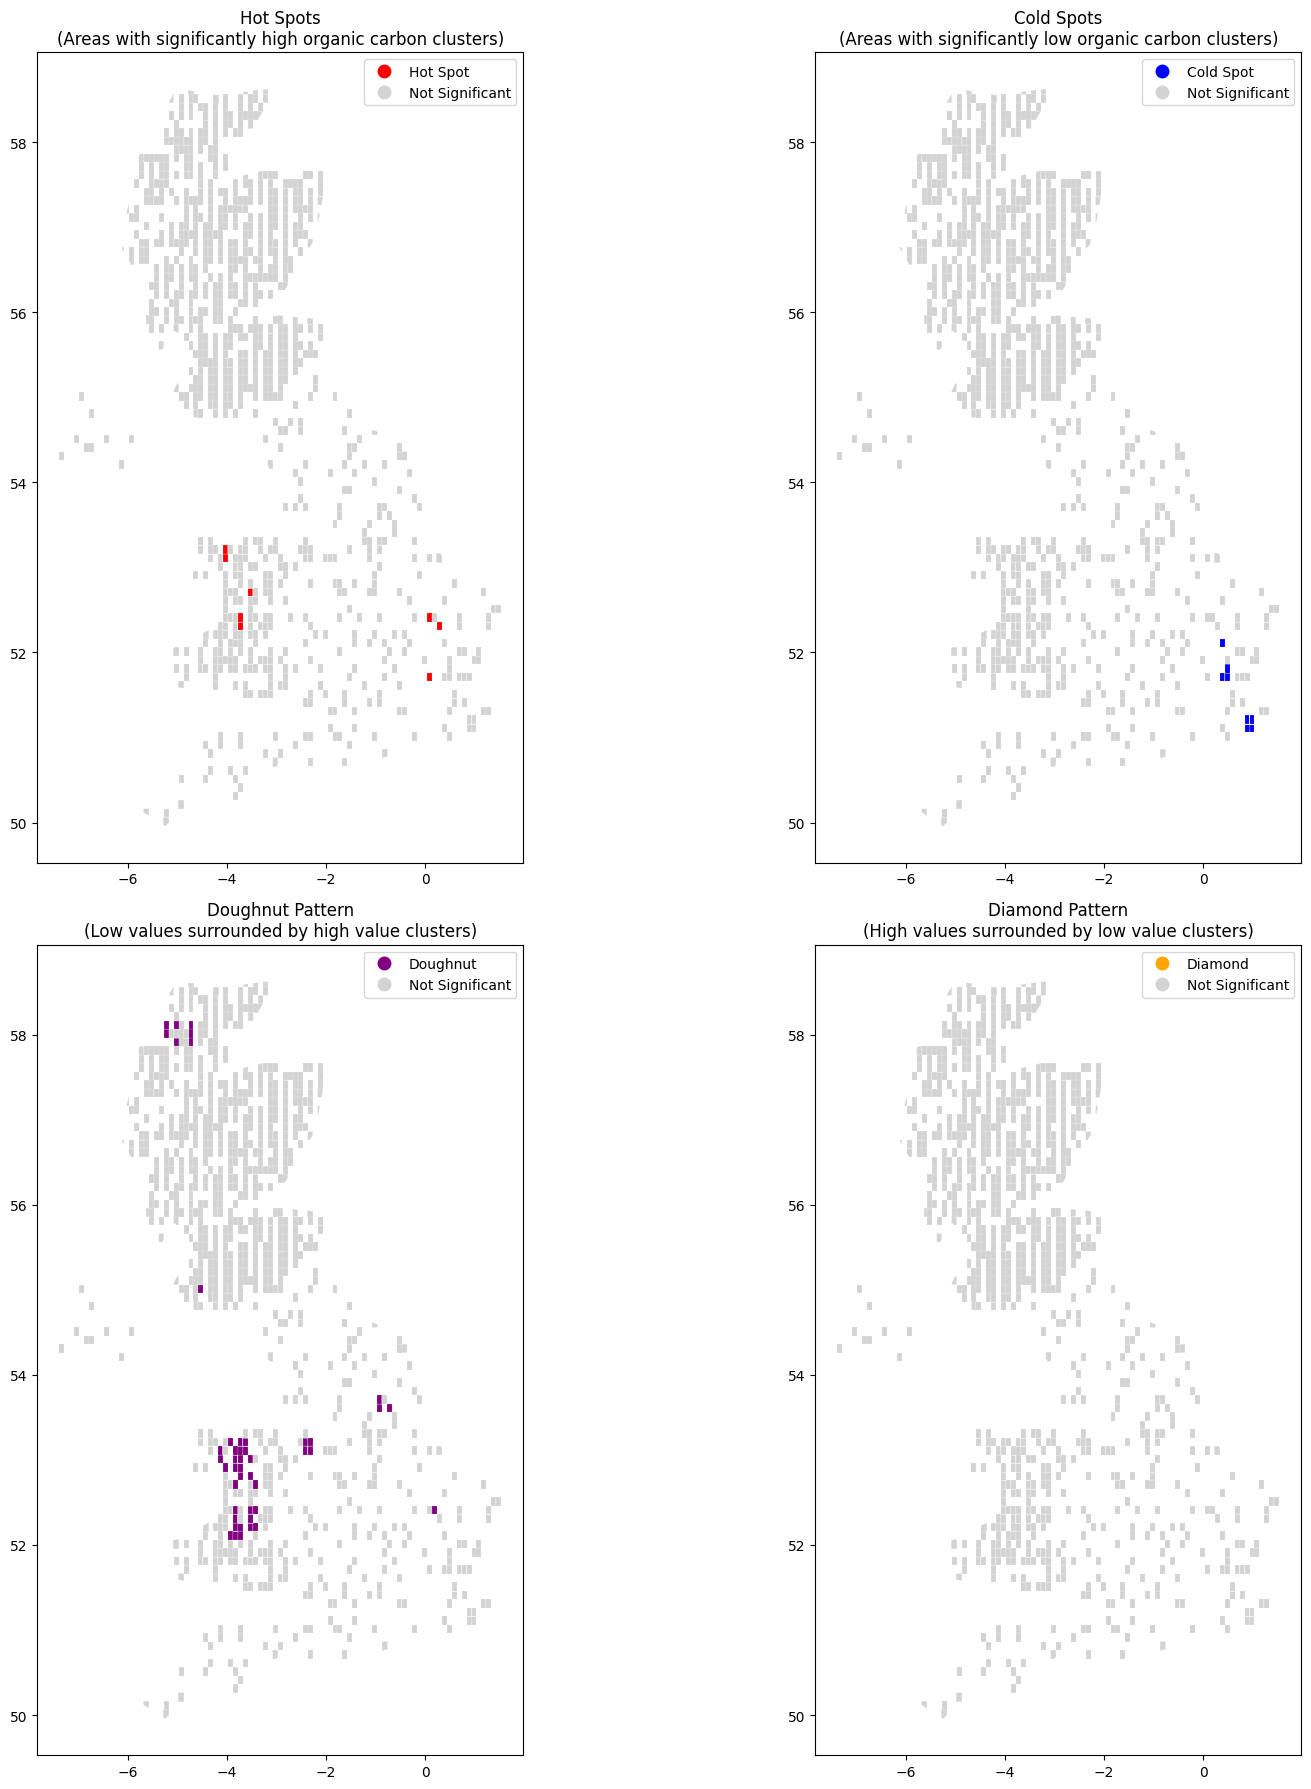


Deep Learning Model Evaluation:
------------------------------
Mean Squared Error:     142.4942
Root Mean Squared Error: 11.9371
Mean Absolute Error:    5.8082
R² Score:              0.9637
------------------------------


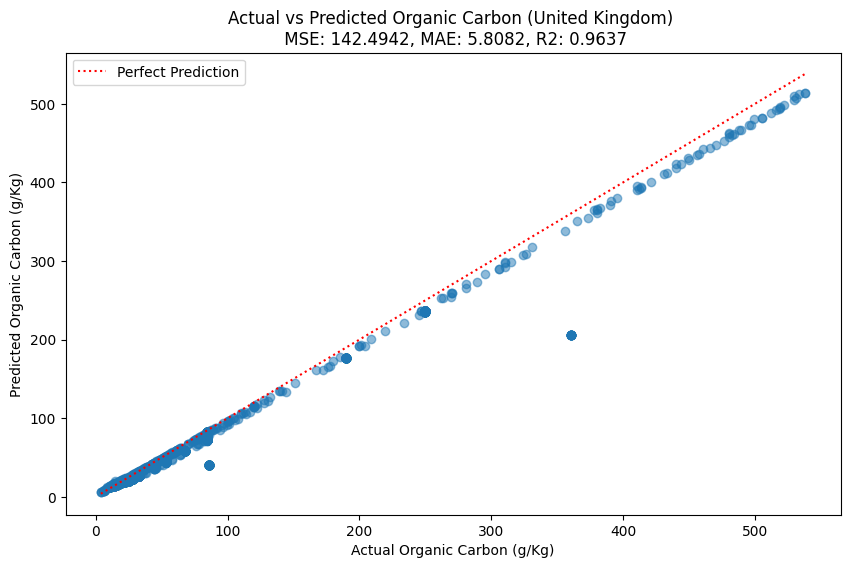

,geometry,upper_depth,lower_depth,elcosp,orgc,phaq,sand,tceq,temperature,precipitation,landcover,latitude,longitude,organic_matter,bulk_density,silt_plus_clay,spatial_lag,moran_i,hotspot,coldspot,doughnut,diamond,target_binary,mean_dist_knn,knn_target_mean,dist_to_hotspot
grid_id,,,,,,,,,,,,,,,,,,,,,,,,,,
21,"POLYGON ((-7.37217 54.36, -7.27217 54.36, -7.2...",0.0,20.0,0.0,84.455623,5.169256,40.747573,59.731763,11.233394,56.777856,10.439585,54.283001,-7.344,145.601494,-7.11609,0.0,84.455623,4.568170e-08,0,0,0,0,0,0.0,84.455623,278448.023027
21,"POLYGON ((-7.37217 54.36, -7.27217 54.36, -7.2...",0.0,20.0,0.0,84.455623,5.169256,40.747573,59.731763,12.451191,60.189629,9.000000,54.285000,-7.346,145.601494,-7.11609,0.0,84.455623,4.568170e-08,0,0,0,0,0,0.0,84.455623,278448.023027
21,"POLYGON ((-7.37217 54.36, -7.27217 54.36, -7.2...",0.0,20.0,0.0,84.455623,5.169256,40.747573,59.731763,4.944138,99.032089,10.439585,54.285000,-7.346,145.601494,-7.11609,3.7,84.455623,4.568170e-08,0,0,0,0,0,0.0,84.455623,278448.023027
21,"POLYGON ((-7.37217 54.36, -7.27217 54.36, -7.2...",0.0,20.0,0.0,84.455623,5.169256,40.747573,59.731763,12.812356,102.377121,14.000000,54.285000,-7.346,145.601494,-7.11609,0.0,84.455623,4.568170e-08,0,0,0,0,0,0.0,84.455623,278448.023027
21,"POLYGON ((-7.37217 54.36, -7.27217 54.36, -7.2...",0.0,20.0,0.0,84.455623,5.169256,40.747573,59.731763,5.239675,45.941082,10.439585,54.285000,-7.346,145.601494,-7.11609,2.4,84.455623,4.568170e-08,0,0,0,0,0,0.0,84.455623,278448.023027
21,"POLYGON ((-7.37217 54.36, -7.27217 54.36, -7.2...",0.0,20.0,0.0,84.455623,5.169256,40.747573,59.731763,11.233394,56.777856,10.439585,54.285000,-7.346,145.601494,-7.11609,36.9,84.455623,4.568170e-08,0,0,0,0,0,0.0,84.455623,278448.023027
21,"POLYGON ((-7.37217 54.36, -7.27217 54.36, -7.2...",0.0,20.0,0.0,84.455623,5.169256,40.747573,59.731763,2.760136,39.559364,10.439585,54.285000,-7.346,145.601494,-7.11609,45.1,84.455623,4.568170e-08,0,0,0,0,0,0.0,84.455623,278448.023027
56,"POLYGON ((-7.07217 54.56, -6.97217 54.56, -6.9...",0.0,20.0,0.0,84.455623,5.169256,40.747573,59.731763,11.233394,56.777856,10.439585,54.509998,-6.990,145.601494,-7.11609,1.8,84.455623,4.568170e-08,0,0,0,0,0,0.0,84.455623,272395.128445
56,"POLYGON ((-7.07217 54.56, -6.97217 54.56, -6.9...",0.0,20.0,0.0,84.455623,5.169256,40.747573,59.731763,3.899828,88.534355,10.439585,54.509998,-6.990,145.601494,-7.11609,24.6,84.455623,4.568170e-08,0,0,0,0,0,0.0,84.455623,272395.128445


In [ ]:
# United Kingdom dataset
uk_grid_gdf = load_grids("D:/tierra/data/grids/United Kingdom/United Kingdom_grid_10.0km.shp")
uk_gdf = load_test_dataset("D:/tierra/data/United Kingdom_wosis_merged_all.csv", df, uk_grid_gdf)
plot_moran_patterns(uk_gdf)
test_model(uk_gdf, MODEL, SCALAR)
# save dataset
uk_gdf.set_index('grid_id', inplace=True)
uk_gdf.to_csv("D:/tierra/datasets/dl_uk_dataset.csv")
# uk_gdf.head(10)